In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models, optimizers, losses
import matplotlib.pyplot as plt

In [ ]:
# load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

In [ ]:
# make a CNN model
def make_model():
    inp = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation='relu')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(10, activation='softmax')(x)
    return models.Model(inp, out)

model = make_model()
model.compile(optimizer=optimizers.Adam(1e-3),
              loss=losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
# train the model
model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9322 - loss: 0.2215 - val_accuracy: 0.9788 - val_loss: 0.0718
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9803 - loss: 0.0632 - val_accuracy: 0.9867 - val_loss: 0.0463
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9861 - loss: 0.0444 - val_accuracy: 0.9867 - val_loss: 0.0433


In [ ]:
# FGSM function (batch-capable)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

In [ ]:
@tf.function
def fgsm_step(images, labels, epsilon):
    images = tf.cast(images, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(images)
        preds = model(images, training=False)
        loss = loss_object(labels, preds)
    grad = tape.gradient(loss, images)
    signed_grad = tf.sign(grad)
    adv_images = images + epsilon * signed_grad
    adv_images = tf.clip_by_value(adv_images, 0.0, 1.0)
    return adv_images


In [10]:
# create adversarial test set
epsilon = 0.15
batch_size = 128
adv_list = []
for i in range(0, len(x_test), batch_size):
    xb = x_test[i:i+batch_size]
    yb = y_test[i:i+batch_size]
    adv = fgsm_step(xb, yb, epsilon).numpy()
    adv_list.append(adv)
x_test_adv = np.vstack(adv_list)


In [11]:
# evaluate
print("Clean test eval:")
print(model.evaluate(x_test, y_test, verbose=0))
print(f"Adversarial test eval (epsilon={epsilon}):")
print(model.evaluate(x_test_adv, y_test, verbose=0))

Clean test eval:
[0.03955649212002754, 0.987500011920929]
Adversarial test eval (epsilon=0.15):
[0.9778937697410583, 0.6672000288963318]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


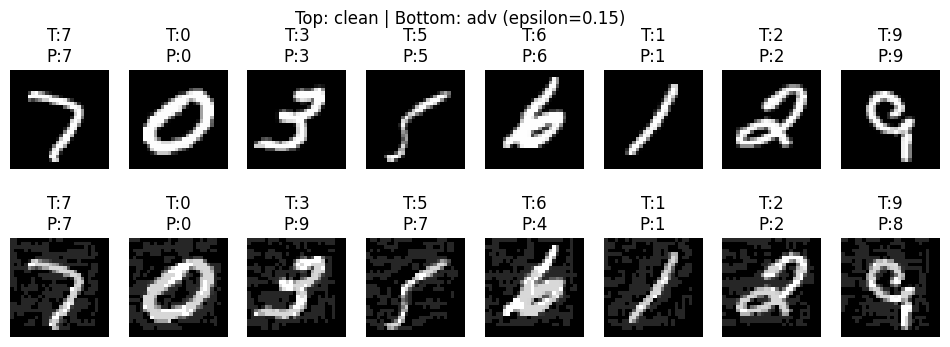

In [12]:
# visualize a few examples
import random
idx = random.sample(range(len(x_test)), 8)
fig, axes = plt.subplots(2, len(idx), figsize=(len(idx)*1.5,4))
for i, idv in enumerate(idx):
    axes[0,i].imshow(x_test[idv].squeeze(), cmap='gray'); axes[0,i].axis('off')
    axes[0,i].set_title(f"T:{y_test[idv]}\nP:{np.argmax(model.predict(x_test[idv:idv+1]))}")
    axes[1,i].imshow(x_test_adv[idv].squeeze(), cmap='gray'); axes[1,i].axis('off')
    axes[1,i].set_title(f"T:{y_test[idv]}\nP:{np.argmax(model.predict(x_test_adv[idv:idv+1]))}")
plt.suptitle(f"Top: clean | Bottom: adv (epsilon={epsilon})")
plt.show()